# 04. Экономический расчёт проекта
**Цель**: Оценить затраты на разработку, эксплуатацию и экономический эффект от внедрения системы прогнозирования спроса.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from config.settings import REPORTS_PATH, resolve_data_path

# Настройка
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")

In [41]:
# 1. Загрузка метрик модели
with open(REPORTS_PATH / "model_results.json", "r", encoding="utf-8") as f:
    model_results = json.load(f)

best_mape = model_results["best_mape"]
best_model = model_results["best_model"]

print(f"Лучшая модель: {best_model}")
print(f"MAPE: {best_mape:.2f}%")

Лучшая модель: LightGBM
MAPE: 9.70%


In [18]:
# 2. Параметры расчета

# Загрузка данных для расчета бизнес-параметров
df = pd.read_csv(resolve_data_path("processed", "cleaned"), parse_dates=["Date"])

# Трудозатраты (сценарий промышленного внедрения)
team = {
    "Data Engineer": {"rate": 2500, "hours_day": 8, "days": 90},
    "ML Engineer": {"rate": 2800, "hours_day": 8, "days": 60},
    "Аналитик": {"rate": 2000, "hours_day": 6, "days": 40},
    "DevOps": {"rate": 2600, "hours_day": 4, "days": 30},
    "PM": {"rate": 2200, "hours_day": 4, "days": 90}
}

# Оборудование
pc_cost = 80000 # Стоимость ПК на разработчика, руб
pc_count = len(team)
pc_lifetime_years = 5 # Срок использования, лет

# Накладные расходы
electricity_monthly = 500 # Электричество, руб/мес
internet_monthly = 800 # Интернет, руб/мес
dev_months = 90 / 22 # Длительность проекта в месяцах (22 рабочих дня)

# Бизнес-параметры (Rossmann)
n_stores = df["Store"].nunique() # Количество магазинов в сети
avg_daily_revenue = df[df["Sales"] > 0]["Sales"].mean() # Средний оборот магазина, €/день
working_days_year = 300 # Рабочих дней в году
overstock_cost_pct = 0.03 # Потери от избыточных запасов (% от оборота)
understock_cost_pct = 0.05 # Потери от дефицита (% от оборота)
baseline_forecast_error = 25 # Ошибка прогноза без ML-системы, %

print(f"Команда: {len(team)} специалистов, длительность: {dev_months:.1f} мес")
print(f"Средний оборот магазина: {avg_daily_revenue:,.0f} €/день (рабочие дни)")

Команда: 5 специалистов, длительность: 4.1 мес
Средний оборот магазина: 6,941 €/день (рабочие дни)


In [42]:
# 3. Затраты на разработку
# Оплата труда команды
labor_cost = sum(p["rate"] * p["hours_day"] * p["days"] for p in team.values())

# Армотизация ПК за период разработки
annual_depreciation = (pc_cost * pc_count) / pc_lifetime_years
depreciation_dev = annual_depreciation * (dev_months / 12)

# Стоимость ПО (open-source стек -> 0)
software_cost = 0

# Накладные расходы
overhead_cost = (electricity_monthly * pc_count + internet_monthly) * dev_months

# Интеграция с ERP (оценка)
integration_cost = 500000

# Итого разработано
total_dev_cost = labor_cost + depreciation_dev + software_cost + overhead_cost + integration_cost

print(f"Затраты на разработку: {total_dev_cost:,.0f} руб")
print(f"Оплата труда: {labor_cost/total_dev_cost*100:.0f}% затрат, интеграция с ERP: {integration_cost:,.0f} руб, ПО: 0 руб (open-source)")

Затраты на разработку: 5,268,773 руб
Оплата труда: 90% затрат, интеграция с ERP: 500,000 руб, ПО: 0 руб (open-source)


In [20]:
# 4. Годовые затраты на эксплуатацию
# Сопровождение (отраслевой норматив 15-25% от трудозатрат)
maintenance_cost = labor_cost * 0.20

# Серверная инфраструктура (production-уровень)
server_cost_annual = 360000 # Облачный кластер, руб/год

# Амортизация ПК (годовая, 2 сотрудника на поддержке)
depreciation_annual = (pc_cost * 2) / pc_lifetime_years

# Итого эксплуатация
total_ops_cost = maintenance_cost + server_cost_annual + depreciation_annual

print(f"Годовая эксплуатация: {total_ops_cost:,.0f} руб")

Годовая эксплуатация: 1,337,600 руб


In [32]:
# 5. Экономический эффект от внедрения
# Модельный расчёт для группы магазинов (сценарий первичного внедрения)
n_target_stores = 50

# Снижение ошибки прогноза -> снижение потерь от overstock/understock
annual_revenue = n_target_stores * avg_daily_revenue * working_days_year

# Потери от неточного прогнозирования (базовый сценарий - без системы)
loss_rate_baseline = (overstock_cost_pct + understock_cost_pct) * (baseline_forecast_error / 100)
annual_loss_baseline = annual_revenue * loss_rate_baseline

# Потери с ML-системной (MAPE модели)
loss_rate_ml = (overstock_cost_pct + understock_cost_pct) * (best_mape / 100)
annual_loss_ml = annual_revenue * loss_rate_ml

# Экономия
realization_rate = 0.10  # Коэффициент реализуемости (не все решения о закупках основаны на прогнозе)
annual_saving_eur = (annual_loss_baseline - annual_loss_ml) * realization_rate
eur_to_rub = 100 # Курс €/руб (параметрическое допущение)
annual_saving_rub = annual_saving_eur * eur_to_rub
error_reduction = baseline_forecast_error - best_mape

print(f"Расчёт для {n_target_stores} магазинов из {n_stores}")
print(f"Снижение ошибки: {baseline_forecast_error}% -> {best_mape:.1f}% (-{error_reduction:.1f} п.п.)")
print(f"Годовая экономия: {annual_saving_eur:,.0f} € ({annual_saving_rub:,.0f} руб)")

Расчёт для 50 магазинов из 1115
Снижение ошибки: 25% -> 9.7% (-15.3 п.п.)
Годовая экономия: 127,424 € (12,742,440 руб)


In [33]:
# 6. ROI и срок окупаемости
# Чистый годовой эффект = экономия - эксплуатация
net_annual_effect = annual_saving_rub - total_ops_cost

# ROI = (Чистый эффект / Затраты на разработку) * 100
roi = (net_annual_effect / total_dev_cost) * 100

# Срок окупаемости (месяцев)
if net_annual_effect > 0:
    payback_months = (total_dev_cost / net_annual_effect) * 12
else:
    payback_months = float("inf")

print(f"ROI: {roi:.1f}%, срок окупаемости: {payback_months:.1f} мес")

ROI: 216.5%, срок окупаемости: 5.5 мес


СРОК ОКУПАЕМОСТИ (мес) при разных сценариях
Строки: базовая ошибка без системы, Столбцы: MAPE модели



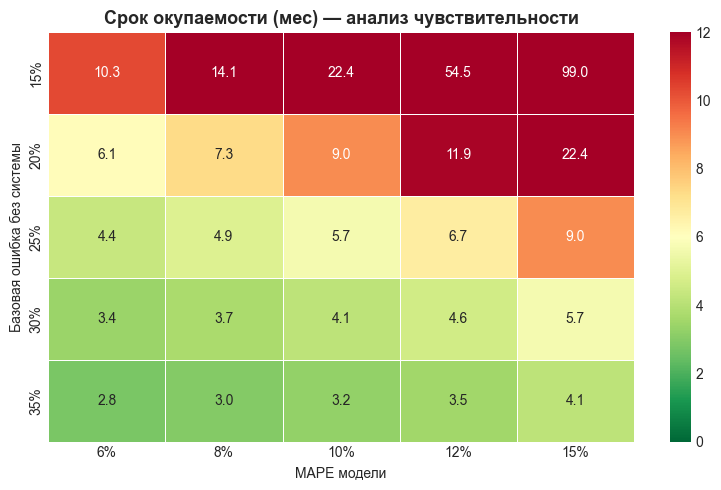

In [35]:
# 7. Анализ чувствительности
# Срок окупаемости при разных MAPE и базовой ошибке
mape_range = [6, 8, 10, 12, 15]
baseline_range = [15, 20, 25, 30, 35]
total_cost_pct = overstock_cost_pct + understock_cost_pct

# Расчёт матрицы окупаемости
payback_matrix = np.zeros((len(baseline_range), len(mape_range)))

for i, base_err in enumerate(baseline_range):
    for j, ml_err in enumerate(mape_range):
        saving = annual_revenue * total_cost_pct * (base_err - ml_err) / 100 * realization_rate * eur_to_rub
        net_effect = saving - total_ops_cost
        payback_matrix[i, j] = (total_dev_cost / net_effect) * 12 if net_effect > 0 else 99

sensitivity_df = pd.DataFrame(
    payback_matrix,
    index=[f"{v}%" for v in baseline_range],
    columns=[f"{v}%" for v in mape_range]
)

print("СРОК ОКУПАЕМОСТИ (мес) при разных сценариях")
print(f"Строки: базовая ошибка без системы, Столбцы: MAPE модели")
print()

plt.figure(figsize=(8, 5))
sns.heatmap(sensitivity_df, annot=True, fmt=".1f", cmap="RdYlGn_r", linewidths=0.5, vmin=0, vmax=12)
plt.title("Срок окупаемости (мес) — анализ чувствительности", fontsize=13, fontweight="bold")
plt.xlabel("MAPE модели")
plt.ylabel("Базовая ошибка без системы")
plt.tight_layout()
plt.savefig(REPORTS_PATH / "sensitivity_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

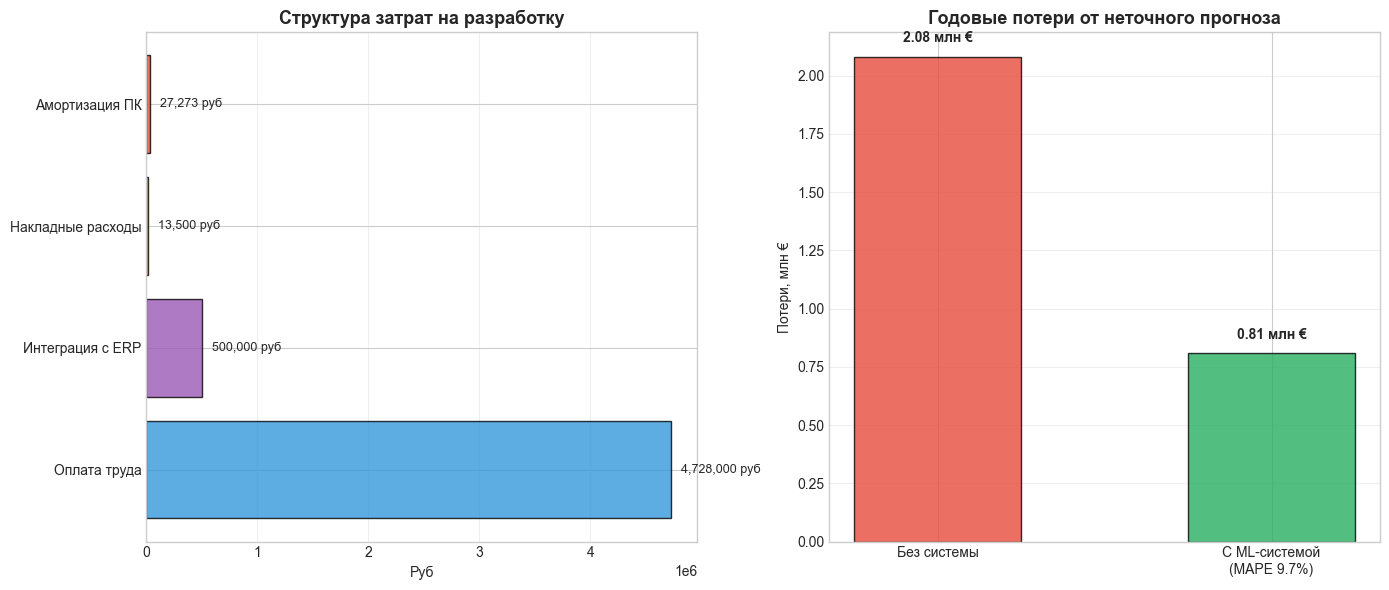

In [37]:
# 8. Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Структура затрат на разработку
cost_labels = ["Оплата труда", "Интеграция с ERP", "Накладные расходы", "Амортизация ПК"]
cost_values = [labor_cost, integration_cost, overhead_cost, depreciation_dev]
colors = ["#3498db", "#9b59b6", "#f39c12", "#e74c3c"]

bars = axes[0].barh(cost_labels, cost_values, color=colors, alpha=0.8, edgecolor="black")
for bar, val in zip(bars, cost_values):
    axes[0].text(bar.get_width() + max(cost_values)*0.02, bar.get_y() + bar.get_height()/2,
                f"{val:,.0f} руб", ha="left", va="center", fontsize=9)

axes[0].set_title("Структура затрат на разработку", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Руб")
axes[0].grid(True, alpha=0.3, axis="x")

# Сравнение потерь: без системы vs с ML
scenarios = ["Без системы", f"С ML-системой\n(MAPE {best_mape:.1f}%)"]
losses = [annual_loss_baseline / 1000000, annual_loss_ml / 1000000]
bar_colors = ["#e74c3c", "#27ae60"]

bars = axes[1].bar(scenarios, losses, color=bar_colors, alpha=0.8, edgecolor="black", width=0.5)
for bar, val in zip(bars, losses):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f"{val:,.2f} млн €", ha="center", va="bottom", fontweight="bold")

axes[1].set_title("Годовые потери от неточного прогноза", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Потери, млн €")
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(REPORTS_PATH / "economic_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

In [40]:
# 9. Выводы и сохранение
print("ВЫВОДЫ")
print("-"*50)
print(f"1. Затраты на разработку: {total_dev_cost:,.0f} руб (оплата труда {labor_cost/total_dev_cost*100:.0f}%, ПО: 0 руб)")
print(f"2. Снижение ошибки прогноза: {baseline_forecast_error}% -> {best_mape:.1f}%")
print(f"3. Годовая экономия: {annual_saving_eur:,.0f} € ({annual_saving_rub:,.0f} руб)")
print(f"4. ROI: {roi:.1f}%, окупаемость: {payback_months:.1f} мес")
print(f"5. Устойчивость: даже при базовой ошибке 15% система окупается за {sensitivity_df.loc["15%", "10%"]:.0f} мес")

# Сохранение результатов
economic_results = {
    "model": best_model,
    "mape_pct": best_mape,
    "n_target_stores": n_target_stores,
    "realization_rate": realization_rate,
    "development_cost_rub": total_dev_cost,
    "annual_ops_cost_rub": total_ops_cost,
    "annual_saving_eur": round(annual_saving_eur, 2),
    "annual_saving_rub": round(annual_saving_rub, 2),
    "roi_pct": round(roi, 2),
    "payback_months": round(payback_months, 1)
}

results_path = REPORTS_PATH / "economic_results.json"
with open(results_path, "w", encoding="utf-8") as f:
    json.dump(economic_results, f, indent=2, ensure_ascii=False)

print(f"\nРезультаты сохранены: {results_path}")

ВЫВОДЫ
--------------------------------------------------
1. Затраты на разработку: 5,268,773 руб (оплата труда 90%, ПО: 0 руб)
2. Снижение ошибки прогноза: 25% -> 9.7%
3. Годовая экономия: 127,424 € (12,742,440 руб)
4. ROI: 216.5%, окупаемость: 5.5 мес
5. Устойчивость: даже при базовой ошибке 15% система окупается за 22 мес

Результаты сохранены: C:\Users\lunar\PycharmProjects\demand_forecasting\reports\economic_results.json
